EJEMPLO 1: CLASIFICACIÓN (Naranjas)

Salud del Naranjo: Analizar un naranjo y saber si las naranjas están enfermas o sanas.

--- RESULTADO DE LA IA ---
Naranja nueva: 6 manchas y color 3
La IA dice que esta naranja está: ENFERMA (1)


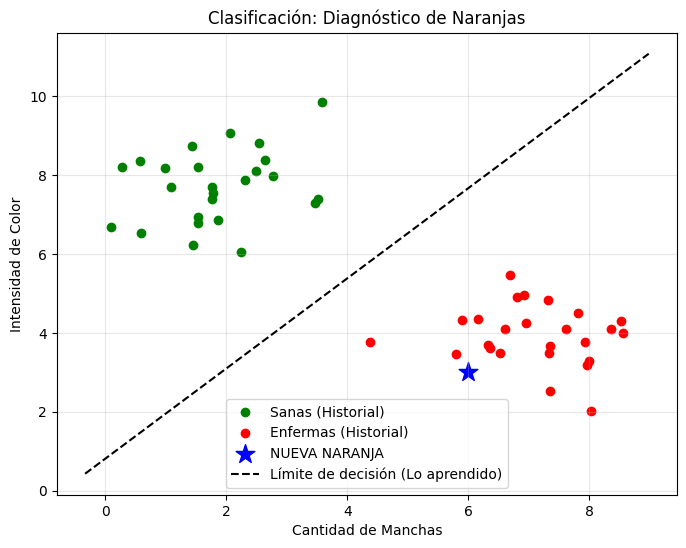

In [7]:
# Importamos las librerias

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 1. GENERAR DATOS (Simulamos 50 naranjas)
np.random.seed(42) # Para que siempre salgan los mismos datos

# Naranjas Sanas (Clase 0): Pocas manchas, buen color
sanas_manchas = np.random.normal(2, 1, 25)  # Media de 2 manchas
sanas_color = np.random.normal(8, 1, 25)    # Color intenso (8)
etiquetas_sanas = np.zeros(25)              # Etiqueta 0 = Sana

# Naranjas Enfermas (Clase 1): Muchas manchas, color pálido
enfermas_manchas = np.random.normal(7, 1, 25) # Media de 7 manchas
enfermas_color = np.random.normal(4, 1, 25)   # Color pálido (4)
etiquetas_enfermas = np.ones(25)              # Etiqueta 1 = Enferma

# Juntamos todos los datos
X = np.column_stack((np.concatenate((sanas_manchas, enfermas_manchas)),
                     np.concatenate((sanas_color, enfermas_color))))
y = np.concatenate((etiquetas_sanas, etiquetas_enfermas))

# 2. ENTRENAR EL MODELO

clf = LogisticRegression()
clf.fit(X, y)

# 3. DEMOSTRACIÓN (Predicción)

# Llega una naranja nueva: Tiene 6 manchas y Color nivel 3
# La IA sabe que 1 o 2 manchas (sano) tambien que nivel 8 o 9 (sano)
naranja_nueva = [[6, 3]]
prediccion = clf.predict(naranja_nueva)
resultado = "ENFERMA (1)" if prediccion[0] == 1 else "SANA (0)"

print(f"--- RESULTADO DE LA IA ---")
print(f"Naranja nueva: {naranja_nueva[0][0]} manchas y color {naranja_nueva[0][1]}")
print(f"La IA dice que esta naranja está: {resultado}")

# 4. GRÁFICO

plt.figure(figsize=(8, 6))

# Dibujar los puntos de entrenamiento
plt.scatter(sanas_manchas, sanas_color, color='green', label='Sanas (Historial)')
plt.scatter(enfermas_manchas, enfermas_color, color='red', label='Enfermas (Historial)')

# Dibujar la naranja nueva
plt.scatter(naranja_nueva[0][0], naranja_nueva[0][1], color='blue', s=200, marker='*', label='NUEVA NARANJA')

# Dibujar la línea de decisión (Frontera)
x_vals = np.array(plt.gca().get_xlim())
y_vals = -(x_vals * clf.coef_[0][0] + clf.intercept_[0]) / clf.coef_[0][1]
plt.plot(x_vals, y_vals, '--', c="black", label="Límite de decisión (Lo aprendido)")

plt.title("Clasificación: Diagnóstico de Naranjas")
plt.xlabel("Cantidad de Manchas")
plt.ylabel("Intensidad de Color")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

EJEMPLO 2: REGRESIÓN (Ventas)


Proyección de Ventas: Estimar cuántas unidades de un producto se venderán el próximo mes.

--- RESULTADO DE LA IA ---
Si inviertes S/.1200 en publicidad...
La IA proyecta que venderás: 219.79 unidades.


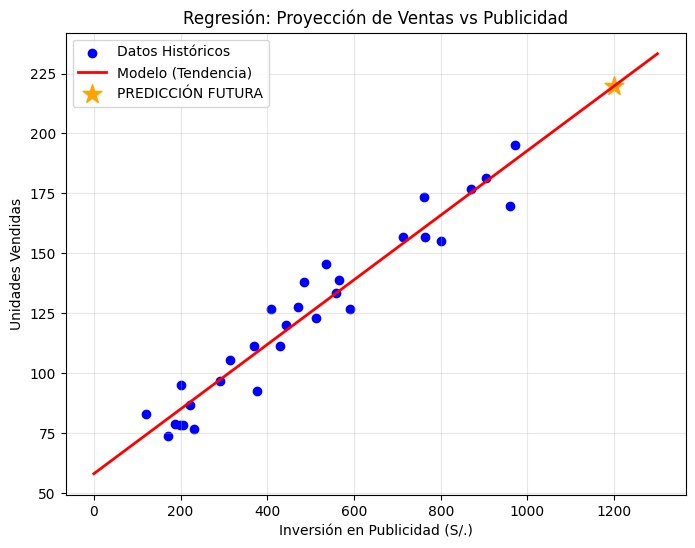

In [6]:
# Importar librerias

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. GENERAR DATOS (Historial de ventas)

np.random.seed(42)

# Simulamos 30 meses de datos
# Inversión entre S/.100 y S/.1000
publicidad = np.random.randint(100, 1000, 30).reshape(-1, 1)

# Las ventas siguen una fórmula: Por cada dólar ganamos 0.5 ventas + un base de 50 + algo de "ruido" aleatorio
ventas = (publicidad * 0.15) + 50 + np.random.normal(0, 10, size=(30, 1))

# 2. ENTRENAR EL MODELO

reg = LinearRegression()
reg.fit(publicidad, ventas)

# 3. DEMOSTRACIÓN (Predicción)

# Queremos saber cuánto venderemos si invertimos S/.1,200 (Nunca hemos invertido tanto antes)
inversion_futura = [[1200]]
prediccion_ventas = reg.predict(inversion_futura)

print(f"--- RESULTADO DE LA IA ---")
print(f"Si inviertes S/.{inversion_futura[0][0]} en publicidad...")
print(f"La IA proyecta que venderás: {round(prediccion_ventas[0][0], 2)} unidades.")

# 4. GRÁFICO

plt.figure(figsize=(8, 6))

# Puntos reales (Historial)
plt.scatter(publicidad, ventas, color='blue', label='Datos Históricos')

# Línea de regresión (Lo que aprendió la IA)
linea_x = np.linspace(0, 1300, 100).reshape(-1, 1)
linea_y = reg.predict(linea_x)
plt.plot(linea_x, linea_y, color='red', linewidth=2, label='Modelo (Tendencia)')

# El punto de predicción futura
plt.scatter(inversion_futura, prediccion_ventas, color='orange', s=200, marker='*', label='PREDICCIÓN FUTURA')

plt.title("Regresión: Proyección de Ventas vs Publicidad")
plt.xlabel("Inversión en Publicidad (S/.)")
plt.ylabel("Unidades Vendidas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()